In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install wordcloud matplotlib

import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Muhammad Yahya Ayyasy_Tugas 21 Agustus 2026/data_preprocessed.csv')
# Wajib memastikan data teks bertipe string dan tidak ada NaN agar WordCloud tidak error
df = df.dropna(subset=['teks_processed', 'sentimen'])

teks_positif = ' '.join(df.loc[df['sentimen'] == 'positif', 'teks_processed'].astype(str))
teks_negatif = ' '.join(df.loc[df['sentimen'] == 'negatif', 'teks_processed'].astype(str))

print('Total karakter positif:', len(teks_positif))
print('Total karakter negatif:', len(teks_negatif))

Total karakter positif: 286567
Total karakter negatif: 804188


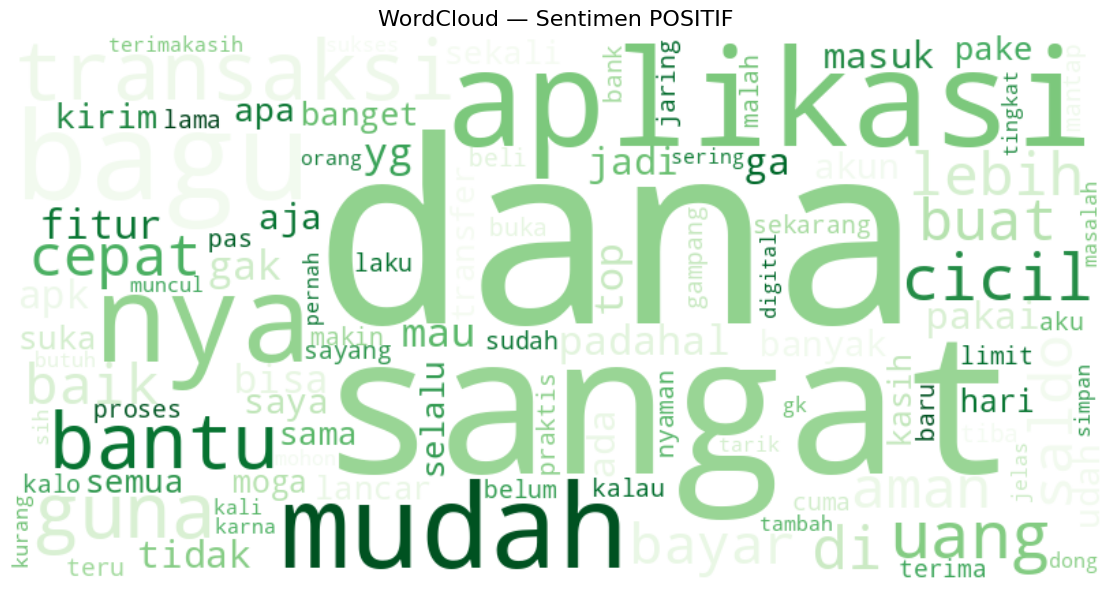

In [4]:
# 3. Buat WordCloud untuk sentimen POSITIF
wc_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(teks_positif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen POSITIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_positif.png', dpi=150, bbox_inches='tight')
plt.show()

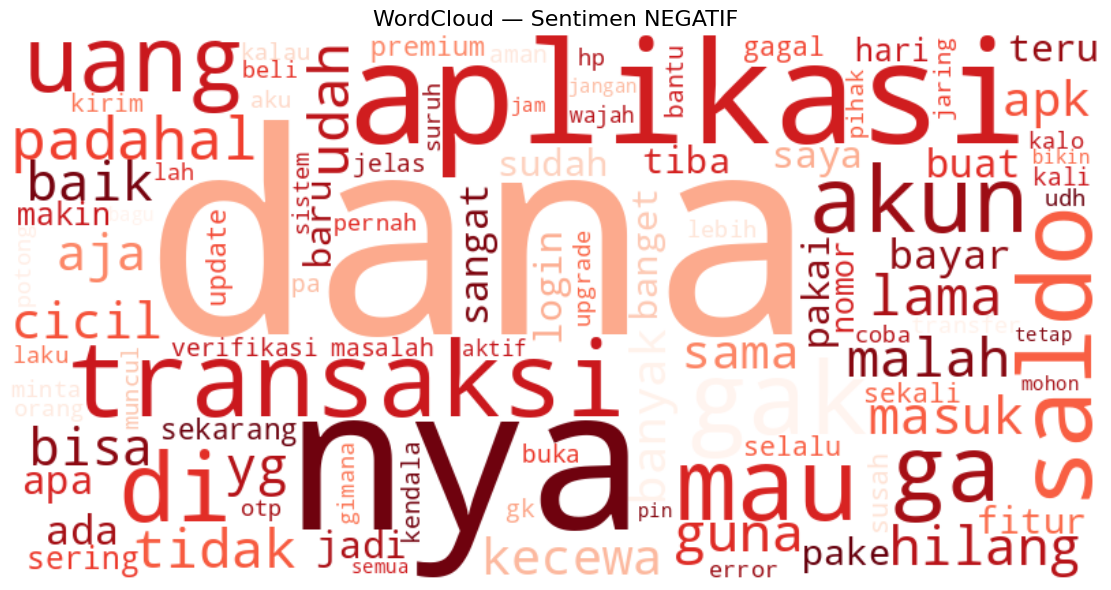

In [5]:
# 4. Buat WordCloud untuk sentimen NEGATIF
wc_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(teks_negatif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen NEGATIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_negatif.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 5. Tampilkan top 10 kata per kelas dalam bentuk tabel
def top_words(teks, n=10):
    kata = teks.split()
    return Counter(kata).most_common(n)

top_pos = top_words(teks_positif, 10)
top_neg = top_words(teks_negatif, 10)

print('\nTop 10 kata POSITIF:')
for k, v in top_pos:
    print(f'  {k:15s} : {v}')

print('\nTop 10 kata NEGATIF:')
for k, v in top_neg:
    print(f'  {k:15s} : {v}')


Top 10 kata POSITIF:
  dana            : 2152
  sangat          : 1125
  aplikasi        : 1052
  bagus           : 862
  nya             : 846
  mudah           : 774
  transaksi       : 729
  guna            : 629
  bantu           : 618
  uang            : 468

Top 10 kata NEGATIF:
  dana            : 5195
  nya             : 2169
  aplikasi        : 2111
  transaksi       : 1604
  mau             : 1540
  saldo           : 1525
  gak             : 1508
  di              : 1359
  ga              : 1294
  akun            : 1252
